# Сводка результатов всех экспериментов

Этот ноутбук собирает `result.csv` из всех экспериментов в единую таблицу  
и строит визуализации для сравнения.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

exp_root = Path().resolve()

## Сбор result.csv из всех экспериментов

In [2]:
GROUP_COLORS = {
    "01_baselines":           "#4e9af1",
    "02_spectrogram_models":  "#f1a44e",
    "03_pretrained_frozen":   "#5cb85c",
    "04_pretrained_finetuned": "#9b59b6",
    "05_ensembles":           "#e74c3c",
    "06_phoneme_analysis":    "#95a5a6",
}

rows = []
for result_csv in sorted(exp_root.glob("**/result.csv")):
    group = result_csv.parts[-3] if len(result_csv.parts) >= 3 else "unknown"
    try:
        df = pd.read_csv(result_csv)
        df["group"] = group
        rows.append(df)
    except Exception as e:
        print(f"Ошибка чтения {result_csv}: {e}")

if rows:
    summary = pd.concat(rows, ignore_index=True)
    summary.to_csv(exp_root / "metrics_summary.csv", index=False, encoding="utf-8")
    print(f"Собрано {len(summary)} результатов")
    display(
        summary[
            ["experiment_id", "experiment_name", "group",
             "accuracy", "f1_macro", "f1_bad", "roc_auc",
             "threshold", "cv_f1_bad_std"]
        ].sort_values("f1_bad", ascending=False)
    )
else:
    print("Нет result.csv — запустите эксперименты")

Собрано 20 результатов


,experiment_id,experiment_name,group,accuracy,f1_macro,f1_bad,roc_auc,threshold,cv_f1_bad_std
18,exp_whisper_finetune,Whisper-small fine-tuning (верхние 4 слоя),04_pretrained_finetuned,0.858513,0.837485,0.779026,0.896506,0.19,NaN
11,exp_whisper_large_v2_svm,Whisper-large-v2 encoder + SVM,03_pretrained,0.839329,0.820204,0.761566,0.909325,0.31,NaN
10,exp_whisper_large_svm,Whisper-large encoder + SVM,03_pretrained,0.839329,0.819568,0.759857,0.906120,0.34,NaN
13,exp_whisper_medium_svm,Whisper-medium encoder + SVM,03_pretrained,0.841346,0.816901,0.750000,0.904732,0.38,NaN
19,exp_embed_fusion_svm,Fusion embeddings: VGGish + HuBERT + Whisper-m...,05_ensembles,0.838942,0.812979,0.743295,0.907895,0.36,NaN
12,exp_whisper_large_v3_svm,Whisper-large-v3 encoder + SVM,03_pretrained,0.831731,0.806584,0.736842,0.908106,0.40,NaN
17,exp_whisper_medium_finetune,Whisper-medium fine-tuning (верхние 8 слоя),04_pretrained_finetuned,0.824519,0.799481,0.728625,0.897904,0.42,NaN
16,exp_whisper_large_v2_finetune,Whisper-large-v2 fine-tuning (верхние 8 слоя),04_pretrained_finetuned,0.822115,0.797899,0.727941,0.869883,0.39,NaN
14,exp_whisper_small_svm,Whisper-small encoder + SVM,03_pretrained,0.827338,0.798821,0.723077,0.894891,0.39,NaN
9,exp_whisper_dysarthria_svm,Whisper-dysarthria encoder + SVM,03_pretrained,0.812500,0.786161,0.711111,0.890734,0.35,NaN


## Сравнение по группам

/var/folders/hg/_4p1k0r14wn1zwlfldvkht8c0000gn/T/ipykernel_6851/2172560058.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(group_data, labels=group_labels_short, patch_artist=True)


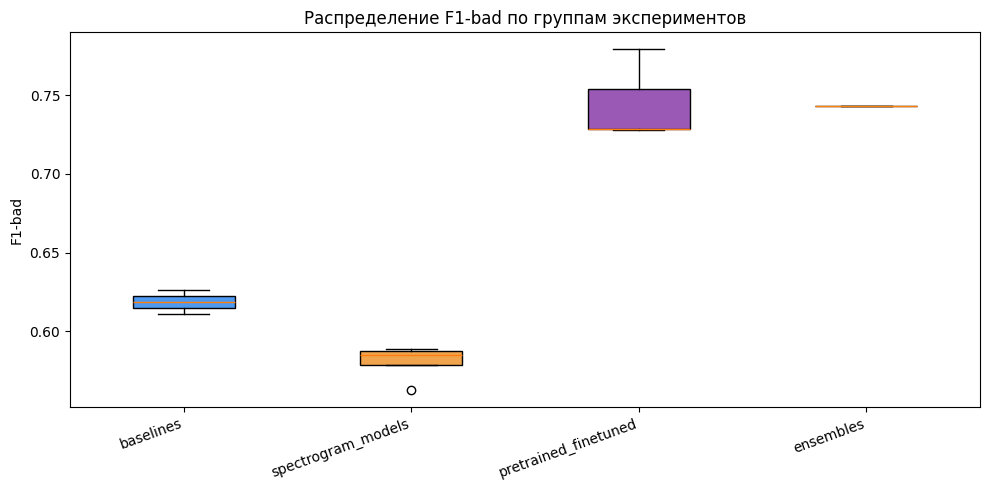

In [3]:
if len(rows) > 0 and len(summary) >= 4:
    group_order = list(GROUP_COLORS.keys())
    group_data = [
        summary[summary["group"] == g]["f1_bad"].dropna().values
        for g in group_order
        if g in summary["group"].values
    ]
    group_labels = [g for g in group_order if g in summary["group"].values]
    group_labels_short = [g.split("_", 1)[1] if "_" in g else g for g in group_labels]

    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(group_data, labels=group_labels_short, patch_artist=True)
    for patch, g in zip(bp["boxes"], group_labels):
        patch.set_facecolor(GROUP_COLORS.get(g, "grey"))
    ax.set_ylabel("F1-bad")
    ax.set_title("Распределение F1-bad по группам экспериментов")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(exp_root / "f1_bad_by_group.png", dpi=150, bbox_inches="tight")
    plt.show()

## Ключевые выводы

In [4]:
if len(rows) > 0:
    best_exp = summary.loc[summary["f1_bad"].idxmax()]
    print(f"Лучший эксперимент: {best_exp['experiment_id']}")
    print(f"  Модель:    {best_exp['experiment_name']}")
    print(f"  F1-bad:    {best_exp['f1_bad']:.4f}")
    print(f"  F1-macro:  {best_exp['f1_macro']:.4f}")
    print(f"  Accuracy:  {best_exp['accuracy']:.4f}")
    print(f"  ROC-AUC:   {best_exp['roc_auc']:.4f}")
else:
    print("Запустите эксперименты и перезапустите этот ноутбук.")

Лучший эксперимент: exp_whisper_finetune
  Модель:    Whisper-small fine-tuning (верхние 4 слоя)
  F1-bad:    0.7790
  F1-macro:  0.8375
  Accuracy:  0.8585
  ROC-AUC:   0.8965
